## SETUP ENVIRONMENT 


In [7]:
import warnings 
warnings. filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# --asthetics--
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## load dataset

In [15]:
import pandas as pd

# Absolute path including the exact subfolders
df = pd.read_csv(r'c:\Users\yared\OneDrive\week-5&6\data\raw\creditcard.csv')

print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## EDA

In [18]:
import pandas as pd
import numpy as np

# 1. Load the data sets
fraud_df = pd.read_csv(r'c:\Users\yared\OneDrive\week-5&6\data\raw\creditcard.csv') # Adjust name to fraud_data.csv if needed
ip_df = pd.read_csv(r'c:\Users\yared\OneDrive\week-5&6\data\raw\IpAddress_to_Country.csv')

In [19]:
# 2. Check for missing values
print("Fraud Data Missing:\n", fraud_df.isnull().sum())
print("IP Data Missing:\n", ip_df.isnull().sum())

Fraud Data Missing:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
IP Data Missing:
 lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64


In [20]:
# Justification: Drop rows if missing target variable/essential keys, 
# or impute numerical fields with median if missing.
fraud_df = fraud_df.dropna() 
ip_df = ip_df.dropna()

In [21]:
# 3. Remove duplicates
fraud_df = fraud_df.drop_duplicates()
ip_df = ip_df.drop_duplicates()

In [26]:
#PIPELINE 1: CREDITCARD.CSV
# ==========================================
print("=== PROCESSING DATASET 1: CREDITCARD.CSV ===")

# 1. Data Cleaning
cc_df = pd.read_csv(RAW_DIR + 'creditcard.csv')
cc_df = cc_df.drop_duplicates()
cc_df = cc_df.dropna()

# 2. Exploratory Data Analysis & Imbalance Quantification
print("\n[CreditCard] Total Transactions:", len(cc_df))
print("[CreditCard] Class Balance (Counts):\n", cc_df['Class'].value_counts())
print("[CreditCard] Class Balance (%):\n", cc_df['Class'].value_counts(normalize=True) * 100)

# 3. Data Transformation & Splitting
X_cc = cc_df.drop(columns=['Class'])
y_cc = cc_df['Class']

# Split first to prevent data leakage
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=42, stratify=y_cc
)

# Scale 'Time' and 'Amount' (V1-V28 are already PCA scaled features)
scaler_cc = StandardScaler()
X_train_cc[['Time', 'Amount']] = scaler_cc.fit_transform(X_train_cc[['Time', 'Amount']])
X_test_cc[['Time', 'Amount']] = scaler_cc.transform(X_test_cc[['Time', 'Amount']])

# 4. Handle Class Imbalance on Training Set
print("\n[CreditCard] Training Class Balance Before SMOTE:", np.bincount(y_train_cc))
smote_cc = SMOTE(random_state=42)
X_train_cc_res, y_train_cc_res = smote_cc.fit_resample(X_train_cc, y_train_cc)
print("[CreditCard] Training Class Balance After SMOTE:", np.bincount(y_train_cc_res))



=== PROCESSING DATASET 1: CREDITCARD.CSV ===


NameError: name 'RAW_DIR' is not defined

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Define the absolute directory path to your file
FILE_PATH = r'c:\Users\yared\OneDrive\week-5&6\data\raw\creditcard.csv'

# Load dataset
df = pd.read_csv(FILE_PATH)

# Data Cleaning
initial_rows = len(df)
df = df.drop_duplicates()
df = df.dropna()
final_rows = len(df)

print(f"Data Cleaning Summary:")
print(f"- Initial rows: {initial_rows}")
print(f"- Removed {initial_rows - final_rows} duplicate or missing entries.")


Data Cleaning Summary:
- Initial rows: 284807
- Removed 1081 duplicate or missing entries.



--- Class Distribution ---
Legitimate (Class 0): 283253 (99.833%)
Fraudulent (Class 1): 473 (0.167%)


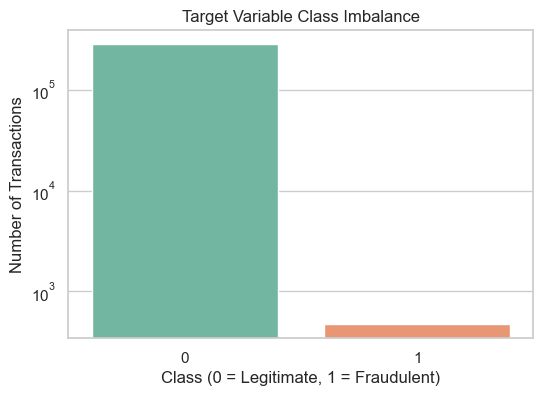

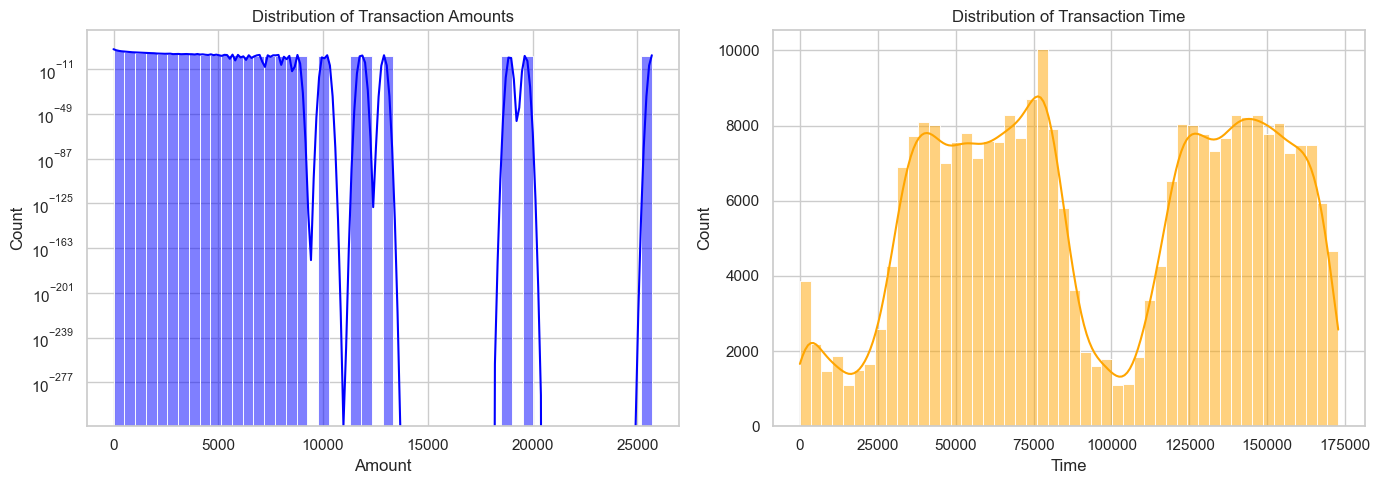

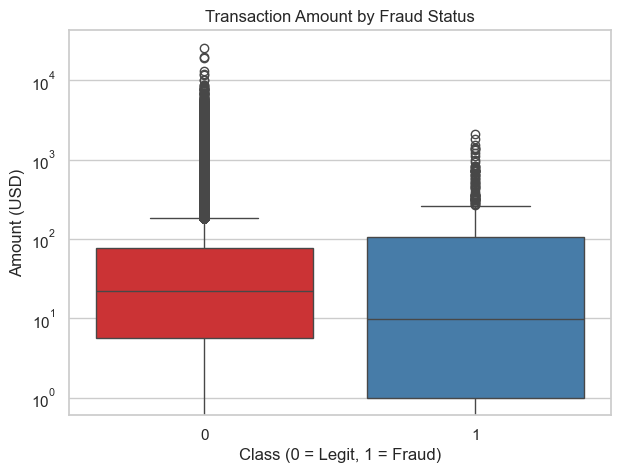

In [29]:
# 1. Quantify Class Imbalance
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("\n--- Class Distribution ---")
print(f"Legitimate (Class 0): {class_counts[0]} ({class_percentages[0]:.3f}%)")
print(f"Fraudulent (Class 1): {class_counts[1]} ({class_percentages[1]:.3f}%)")

# Plot 1: Bar Chart of Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Target Variable Class Imbalance')
plt.xlabel('Class (0 = Legitimate, 1 = Fraudulent)')
plt.ylabel('Number of Transactions')
plt.yscale('log') # Log scale because fraud is extremely small
plt.show()

# Plot 2: Univariate Distribution of Key Variables (Amount and Time)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Transaction Amounts')
axes[0].set_yscale('log') # Log scale handles the extreme outliers in transaction values

sns.histplot(df['Time'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Transaction Time')

plt.tight_layout()
plt.show()

# Plot 3: Bivariate Relationship (Amount vs Target Class)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Class', y='Amount', data=df, palette='Set1')
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Amount (USD)')
plt.yscale('log') # Log scale allows visualization of variances despite extreme numbers
plt.show()


In [30]:
# Separate features and target label
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified Split ensures the tiny minority class is represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize/Scale only 'Time' and 'Amount' (V1-V28 features are already PCA-scaled components)
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("\nData Transformation Status: Scaling of Time and Amount complete.")



Data Transformation Status: Scaling of Time and Amount complete.



--- Training Set Before SMOTE ---
[226602    378]
--- Training Set After SMOTE ---
[226602 226602]


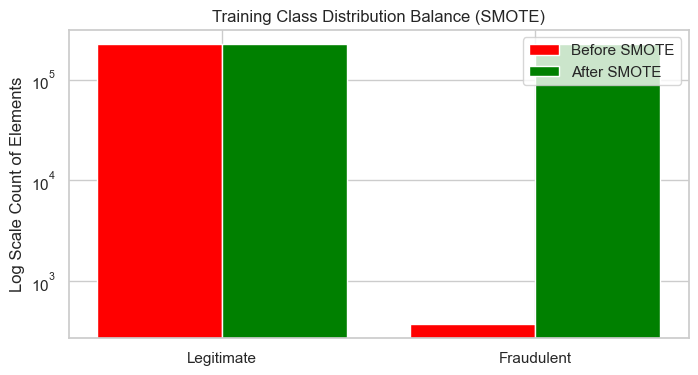

In [31]:
print("\n--- Training Set Before SMOTE ---")
print(np.bincount(y_train))

# Apply SMOTE to training sets exclusively
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("--- Training Set After SMOTE ---")
print(np.bincount(y_train_res))

# Plot 4: Target Distribution Before and After Resampling
plt.figure(figsize=(8, 4))
labels = ['Legitimate', 'Fraudulent']
before_counts = np.bincount(y_train)
after_counts = np.bincount(y_train_res)

x_axis = np.arange(len(labels))
plt.bar(x_axis - 0.2, before_counts, 0.4, label='Before SMOTE', color='red')
plt.bar(x_axis + 0.2, after_counts, 0.4, label='After SMOTE', color='green')

plt.xticks(x_axis, labels)
plt.title('Training Class Distribution Balance (SMOTE)')
plt.ylabel('Log Scale Count of Elements')
plt.yscale('log')
plt.legend()
plt.show()
